# Topic 2: Linear Regression.
## We will load some student data and form a model to predict grade

# 1. Linear Regression**

Linear regression is a foundational statistical method that allows us to model and examine the relationship between two continuous variables. In this case, we are looking at the relationship between median income and median house value.

In this example, we'll use **one (a single)** feature, **'TV Advertising Spend'(x-axis),** to predict the **'Sales (y-axis)'**.

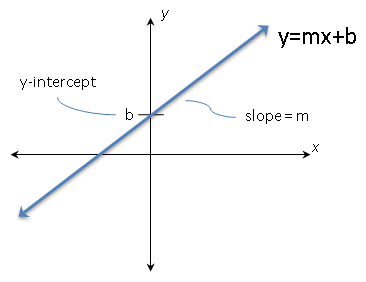

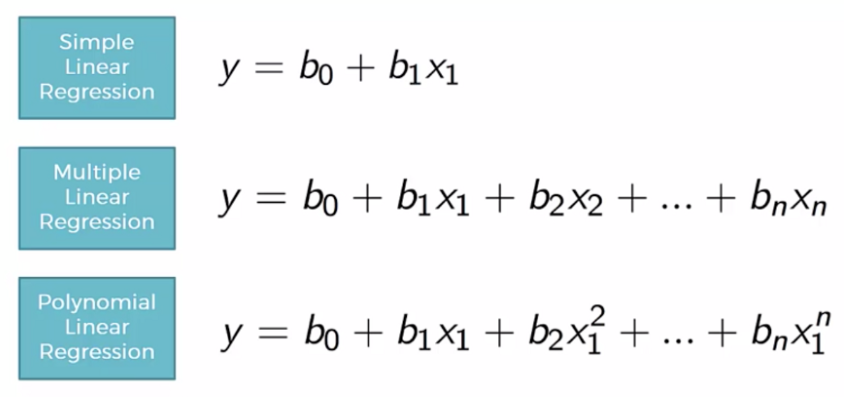

# Pip Installs

In [2]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
from platform import python_version
print(python_version())

3.12.12


# Imports

In [33]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive  # if using colab uncomment this line
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport


# Load the data

In [4]:
# mount the drive if using google colab
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# change the directory to our file location
os.chdir('/content/drive/MyDrive/datasets')

In [6]:
# load our file as a dataframe
filename = 'grades_multi_1000.csv'

df = pd.read_csv(filename)

# Basic EDA

In [7]:
df.head(4)

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
0,110,7,10,17.92,33
1,205,9,18,0.30,82
2,108,6,13,8.37,43
3,485,12,30,4.98,97


In [8]:
# inspect the dataframe with ydata
# https://docs.profiling.ydata.ai/latest/

profile = ProfileReport(df, title="Grade Data Report",explorative=True)
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

In [34]:
# the info method
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hours_Studied          1000 non-null   int64  
 1   Hours_Sleep            1000 non-null   int64  
 2   Number_of_Assignments  1000 non-null   int64  
 3   Dist_from_College      1000 non-null   float64
 4   Grade                  1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


# Ready the data for Machine Learning - split into Train and Test sets

In [35]:
# train test split
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3,
                                     random_state=1234)

In [36]:
print(df.shape)
print(df_train.shape)
print(df_test.shape)


(1000, 5)
(700, 5)
(300, 5)


# Work on the Training set only - keep the Test set for final testing

In [37]:
# look at training data
df_train.head()

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
96,193,8,12,9.31,58
792,283,8,20,2.94,85
218,470,9,24,1.93,94
967,330,14,22,2.63,99
170,133,6,13,2.83,53


In [38]:
df_train.corr(numeric_only = True) # this data is numeric anyway but we should do corr on only numerics

,Hours_Studied,Hours_Sleep,Number_of_Assignments,Dist_from_College,Grade
Hours_Studied,1.000000,0.575416,0.631418,-0.271524,0.727137
Hours_Sleep,0.575416,1.000000,0.695008,-0.279493,0.766590
Number_of_Assignments,0.631418,0.695008,1.000000,-0.311753,0.893652
Dist_from_College,-0.271524,-0.279493,-0.311753,1.000000,-0.361451
Grade,0.727137,0.766590,0.893652,-0.361451,1.000000


### Look at the correlations with Grade to see which variables might be useful for prediction
### Also, look at the correlations between potential features to check for Multicollinearity  (rule of thumb exclude feature if > 0.8)

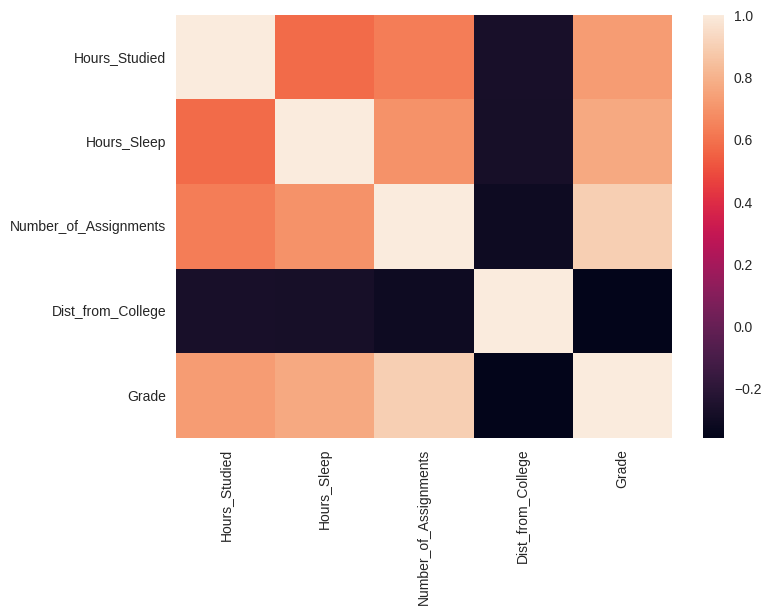

In [39]:
sns.heatmap(df_train.corr());

# Predictive Analytics

In [40]:
# let's look at the column names again
print(df_train.columns)

Index(['Hours_Studied', 'Hours_Sleep', 'Number_of_Assignments',
       'Dist_from_College', 'Grade'],
      dtype='object')


In [41]:
# We need to separate target (y) from the input variables X

X_train = df_train.drop('Grade', axis=1)
X_test = df_test.drop('Grade', axis=1)

y_train = df_train['Grade']
y_test = df_test['Grade']

In [42]:
# we can inspect the arrays
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 4)
(300, 4)
(700,)
(300,)


[Text(0.5, 1.0, 'Grade distribution')]

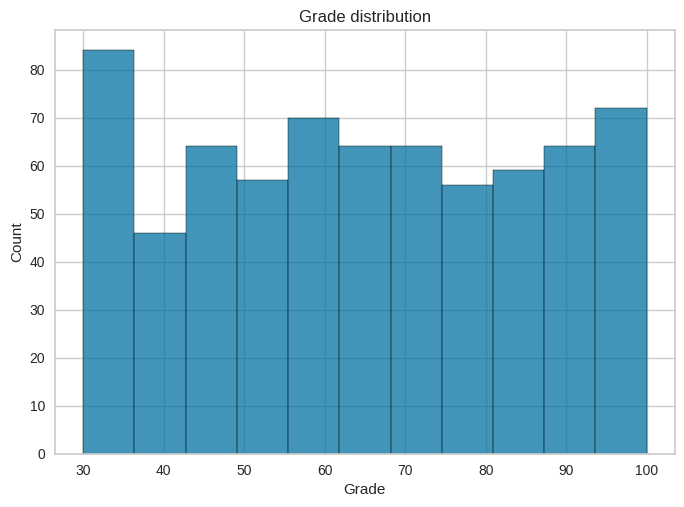

In [43]:
sns.histplot(data=df_train, x='Grade').set(title='Grade distribution')

<Axes: xlabel='Number_of_Assignments', ylabel='Grade'>

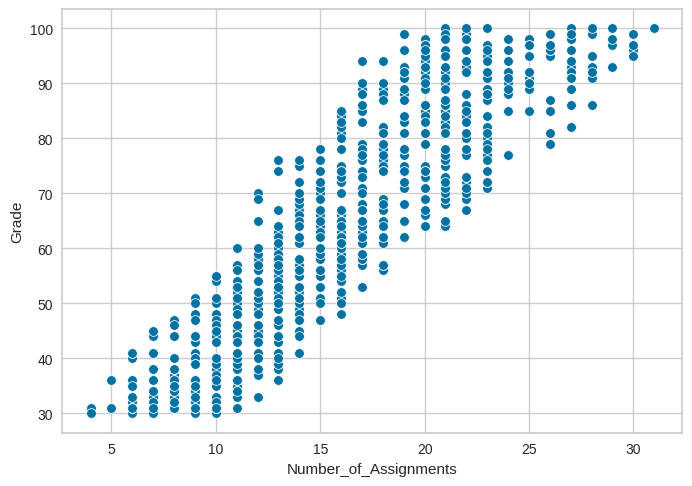

In [44]:
sns.scatterplot(x ="Number_of_Assignments", y ="Grade", data = df_train)

## Training the model

In [45]:
# documentation:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

print(model.score(X_test, y_test))   # this is R squared we will see again in metrics

0.8877345227065315


## Get the intercept and Coefficients

In [46]:
print(model.intercept_)
pd.DataFrame(zip(X_train.columns, model.coef_), columns=["Variable", "Coeff"])

5.262879464414738


,Variable,Coeff
0,Hours_Studied,0.042684
1,Hours_Sleep,2.077058
2,Number_of_Assignments,2.097404
3,Dist_from_College,-0.218471


## Let's look at what model has been built:

Pred Grade =
        5.26 + (0.042684 * Hours_Studied) + (2.077058 * Hours_Sleep) + (2.097404 * Number_of_Assignments) +  (-0.218471 * Dist_from_College)



# Let's manually predict a value


In [47]:
Hours_Studied = 150
Hours_Sleep = 8
Number_of_Assignments = 12
Dist_from_College = 10.5

predicted_Value = 5.26 + (0.042684 * Hours_Studied) + (2.077058 * Hours_Sleep) + (2.097404 * Number_of_Assignments) + (-0.218471 * Dist_from_College)

# print(predicted_Value)
print(f"The predicted value is:  {predicted_Value}")

The predicted value is:  51.1539665


## Explore results

## Let's get predicted results for the unused test set

In [48]:
# get predicted results
y_pred = model.predict(X_test)
y_pred[:10] # print first 10 values

array([88.44080342, 57.97811183, 59.1702554 , 82.11802305, 45.66218848,
       73.24744351, 50.25697492, 73.65238559, 49.14938623, 80.37667791])

# How good is our model?

[Text(0.5, 1.0, 'Actual v Predicted Grades')]

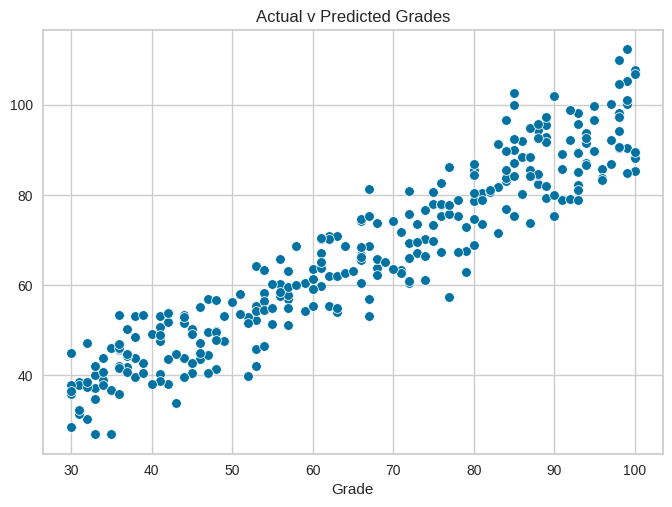

In [49]:
# Data scatter of predicted values

sns.scatterplot(x = y_test, y =y_pred).set(title='Actual v Predicted Grades')


## Metrics to evaluate the model on the test set

| Metric Name | Description | Interpretation | Sklearn Function |
|-------------|-------------|----------------|------------------|
| R² Score | Proportion of variance in the dependent variable that is predictable from the independent variables. | Values range from 0 to 1. A value closer to 1 indicates a better fit. | `sklearn.metrics.r2_score` |
| Mean Absolute Error (MAE) | Average of the absolute differences between predicted values and actual values. It measures the average magnitude of errors in a set of predictions, without considering their direction. | Lower values are better. A value of 0 indicates no error. | `sklearn.metrics.mean_absolute_error` |
| Mean Squared Error (MSE) | Average of the squares of the errors—that is, the average squared difference between the estimated values and the actual value. | Lower values are better. A value of 0 indicates no error. MSE is more sensitive to outliers than MAE. | `sklearn.metrics.mean_squared_error` |
| Root Mean Squared Error (RMSE) | Square root of the average of squared differences between prediction and actual observation. | Lower values are better. A value of 0 indicates no error. RMSE is more sensitive to outliers than MAE. | Not directly in sklearn, calculated as `np.sqrt(sklearn.metrics.mean_squared_error)` |
| Mean Squared Logarithmic Error (MSLE) | Measures the ratio between the true and predicted values. It's the mean of the squared logarithm of the errors. | Lower values are better. A value of 0 indicates no error. Useful when targets having exponential growth, such as population counts. | `sklearn.metrics.mean_squared_log_error` |
| Median Absolute Error | Median of all the absolute differences between the predicted values and actual values. | Lower values are better. Less sensitive to outliers compared to MAE and MSE. | `sklearn.metrics.median_absolute_error` |


### Function to create Mean absolute percentage error (MAPE). This is a more interpretable measure of error

In [50]:
# this is a helper function that when used will return MAPE (mean_absolute_percentage_error)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    try:
      difference = y_true - y_pred
      actual = y_true
      absolute_pct_error = np.mean(np.abs(difference / actual)) * 100
    except Exception:
      absolute_pct_error = 0
    return np.round(absolute_pct_error, decimals=2)

## Run the metrics

In [51]:
# now we need to run our models and evaluate their performance
from sklearn.linear_model import LinearRegression
import sklearn.metrics as met  # https://scikit-learn.org/stable/api/sklearn.metrics.html

# Step 1: initialise the model with its key arguments - if any
model = LinearRegression()

# Step 2: train the model on X_train
model.fit(X_train, y_train)

# Step 3: predict y_pred based on X_test
y_pred = model.predict(X_test)

# Step 4: evaluate and compare y_test vs. y_pred
r2_score = met.r2_score(y_test, y_pred)
# rmse - root mean squared error - unit level
rmse = float(format(np.sqrt(met.mean_squared_error(y_test,y_pred)),'.3f'))
# in % +-
mape = mean_absolute_percentage_error(y_test, y_pred)


print(r2_score)
print(rmse)
print(mape)

0.8877345227065315
7.136
9.96


In hyperparameter tuning, we run many models and collect their results into a table and then sort by our results to find the best models!

In [52]:
# create a results table
# useful when more than 1 model to compare
results = pd.DataFrame({
        'Model_Name': ['Linear_Regression_Basic'],
        'R2 Score': [r2_score],
        'rmse': [rmse],
        'MAPE': [mape]
})

results

,Model_Name,R2 Score,rmse,MAPE
0,Linear_Regression_Basic,0.887735,7.136,9.96


In [53]:
# Using a different package (statsmodels) to run linear regression. It has nicer output....

# use statsmodels
import statsmodels.formula.api as smf

# this is our formula
f = "Grade ~ Hours_Studied + Hours_Sleep + Number_of_Assignments + Dist_from_College"

model_ols = smf.ols(formula=f, data=df_train)   # notice unlike the previous method (sklearn linear regression) it does not separte out the target (i.e Grade) and features (the other columns) separately

model_fit = model_ols.fit()

# To print the summary
print(model_fit.summary())


                            OLS Regression Results                            
Dep. Variable:                  Grade   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     1163.
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          3.39e-306
Time:                        13:19:58   Log-Likelihood:                -2405.1
No. Observations:                 700   AIC:                             4820.
Df Residuals:                     695   BIC:                             4843.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 5.26

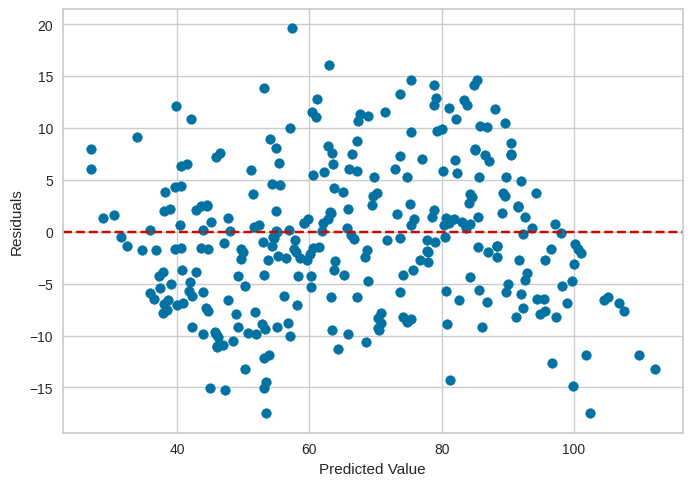

In [54]:
# Let's look at residuals
res = y_test - y_pred
plt.scatter(y_pred, res)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residuals')
plt.show()



# Actionable Recommendations

1) Focus on Sleep and assignments: Given the high ROI and strong correlation with grade, allocate more time for these. The coefficient showed us that for every hour sleep, we got an increase in Grade of 2.08.

2) Think carefully before applying on how far you live from college**:

